In [63]:
%cd E:\SRP\SRP-2025-Project
import os,sys
notebook_dir = os.getcwd()
path = os.path.abspath(os.path.join(notebook_dir, "Code"))
sys.path.append(path)
import torch
from sklearn.metrics import roc_curve, precision_recall_curve,roc_auc_score,average_precision_score
from model import Model
from Dataset import ModelDataset
from torch.utils.data import DataLoader
import pandas as pd
from generateSplits import generateSplits
import matplotlib.pyplot as plt

E:\SRP\SRP-2025-Project


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
metadata = pd.read_csv("../Datasets/BreastDCEDL_spy1/BreastDCEDL_spy1_metadata.csv")
train_df,val_df = generateSplits(metadata,0.2,seed=42)
train_df = train_df[["pid","pCR","ER","PR","HER2"]].set_index("pid",drop=True)
val_df = val_df[["pid","pCR","ER","PR","HER2"]].set_index("pid",drop=True)

In [ ]:
def get_scores(model,val_loader):
    model.eval()
    y_true = []
    y_scores = []
    with torch.no_grad():
        for img,mol,labels in val_loader:
            img=img.to(device)
            mol=mol.to(device)
            labels=labels.to(device)
            logits = model(img,mol)
            score = torch.nn.functional.softmax(logits,dim=1)[:,1]
            y_true.extend(labels.cpu().numpy())
            y_scores.extend(score.cpu().numpy())
    return y_true,y_scores

    

In [72]:
model=Model()
model.to(device)
model.load_state_dict(torch.load(r"models\All_Data_No_Rotation_Trial\model_weights.pth"))
val_dataset = ModelDataset(val_df,class_samples={0:1,1:1},loading_bar = False, caching=True)
val_loader = DataLoader(val_dataset,batch_size=8)
y_true,y_scores = get_scores(model,val_loader)

Dataset initialised with 32 entries.


## ROC

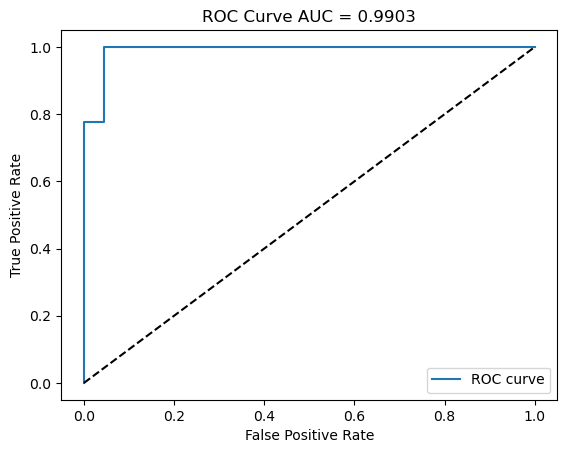

In [73]:
fpr, tpr, _ = roc_curve(y_true, y_scores)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve")
plt.plot([0, 1], [0, 1], 'k--')  # diagonal
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve AUC = {roc_auc_score(y_true, y_scores):.4f}")
plt.legend()
plt.show()

## PR Curve

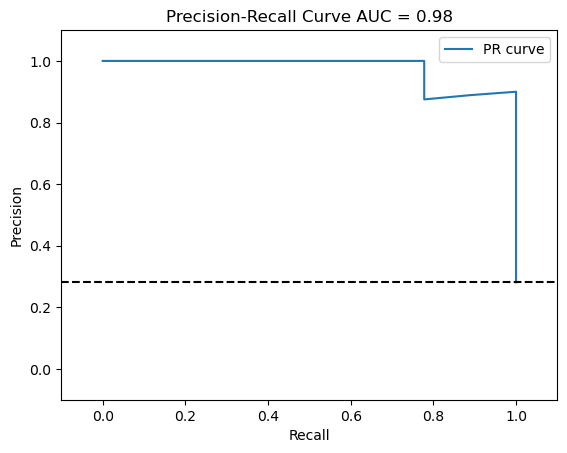

In [74]:
precision, recall, _ = precision_recall_curve(y_true, y_scores)
plt.figure()
plt.plot(recall, precision, label=f"PR curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve AUC = {average_precision_score(y_true,y_scores):.2f}")
plt.hlines(sum(y_true)/len(y_true), -0.1, 1.1, colors='k', linestyles='--')
plt.legend()
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.show()